# Evaluate MNIST Classifier

**Goal:** Evaluate the trained MNIST classifier using test data and performance metrics.


After training, we must check how well the model performs on unseen test data.  
Evaluation ensures the model is not just memorizing but actually learning patterns.

---

## Common Evaluation Metrics
- **Loss** → How wrong the model is.
- **Accuracy** → How often predictions are correct.
- **Confusion Matrix** → Shows correct vs incorrect predictions for each digit.

---

## Layman Explanation
Think of this as checking a student’s **exam results**:
- Loss = number of mistakes made.
- Accuracy = percentage of correct answers.
- Confusion Matrix = detailed report card showing which digits the student confused.


C:\Users\singh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Test Loss: 0.08293532580137253
Test Accuracy: 0.9735000133514404
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step


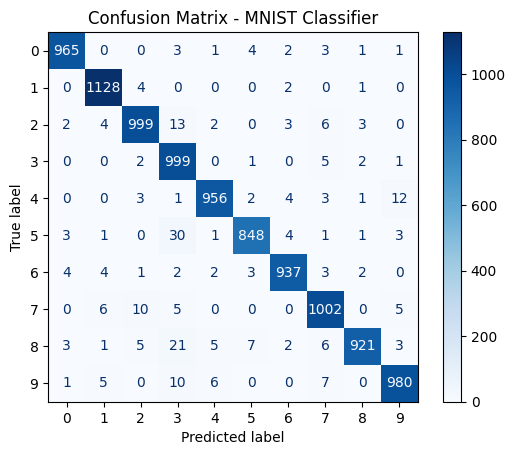

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

# Build model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train briefly
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1, verbose=0)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

# Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix - MNIST Classifier")
plt.show()


- We tested the model on unseen test images.
- Calculated loss (mistakes) and accuracy (score).
- Built a confusion matrix to see which digits were predicted correctly or wrongly.

Layman:
It’s like giving the student a final exam:
- Loss = number of wrong answers.
- Accuracy = overall score.
- Confusion matrix = detailed subject-wise performance (which digits they got confused about).
